# Лабораторная работа 8

Тема: **Свёрточные нейросети (CNN) для CIFAR‑10 в PyTorch**  
Цель: построить и исследовать собственную свёрточную сеть для классификации изображений CIFAR‑10, понять, как архитектура и гиперпараметры влияют на качество.

> Этот ноутбук специально оформлен как практическое задание.  
> Код даёт каркас, но **основные баллы** ставятся за ваши эксперименты и ваши тексты.  
> Если вы просто скормите ноутбук генеративной модели и вставите сгенерированные ответы, это будет видно по стилю и несоответствию коду/графикам.


## 1. Ваши ожидания от CNN

Перед началом работы поставьте скачиваться CIFAR‑10 и зафиксируйте своё понимание:

1. Чем, с вашей точки зрения, свёрточная сеть отличается от "обычного" MLP, если объяснять без формул, на интуитивном уровне.  
2. Почему для картинок обычно используют CNN, а не только полносвязные слои.  
3. Какую примерно точность на CIFAR‑10 вы считаете "разумной" для простой самодельной CNN (не топовой).

Пишите 6–10 предложений, на нормальном языке, как если бы объясняли одногруппнику.


In [2]:
intro_text = """1) Свёрточная нейросеть предназначена для обработки данных с пространственной структурой, такие как изображения.
    CNN в отличии от MLP смотрит на изображения частями, а не длинным списком чисел. CNN ищет линии, края, формы, а потом понимает какой это объект.
    MLP получает пиксели картинок и пытается понять какой объект по закономерностям.

2)Для картинок обычно используют CNN, потому что она лучше учитывает пространственную структуру картинки и требует меньше параметров.
    Если использовать только полносвязные слои, то модель будет большой и долго обучаться. 
    Можно их использовать совместно с CNN  на завершающих этапах.

3) Для простой самодельной CNN я считаю примерная точность будет 70-80%
"""
print(intro_text)

1) Свёрточная нейросеть предназначена для обработки данных с пространственной структурой, такие как изображения.
    CNN в отличии от MLP смотрит на изображения частями, а не длинным списком чисел. CNN ищет линии, края, формы, а потом понимает какой это объект.
    MLP получает пиксели картинок и пытается понять какой объект по закономерностям.

2)Для картинок обычно используют CNN, потому что она лучше учитывает пространственную структуру картинки и требует меньше параметров.
    Если использовать только полносвязные слои, то модель будет большой и долго обучаться. 
    Можно их использовать совместно с CNN  на завершающих этапах.

3) Для простой самодельной CNN я считаю примерная точность будет 70-80%



## 2. Импорт библиотек и настройка среды

Сделаем стандартные шаги:
- импорт PyTorch и torchvision;
- настройка отрисовки графиков;
- фиксация seed (выберите число сами);
- определение устройства (`cpu` или `cuda`).


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Ваш личный seed (заполните его)
MY_SEED = 22
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 22


## 3. CIFAR‑10: загрузка, нормализация, первичный просмотр

Загрузим CIFAR‑10 через `torchvision.datasets.CIFAR10`.

Сделаем:
- перевод в тензор (`ToTensor`);
- нормализацию по каналам (можно использовать стандартные значения для CIFAR‑10);
- DataLoader для train и test.


In [13]:
batch_size = 128 # при выполнении работы попробуйте хотя бы ещё одно значение

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = train_dataset.classes
print("Классы CIFAR‑10:", classes)
print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

Классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размер train: 50000
Размер test : 10000
batch_size = 128


Посмотрим на несколько изображений, чтобы глазами увидеть разнообразие классов и качество картинок.


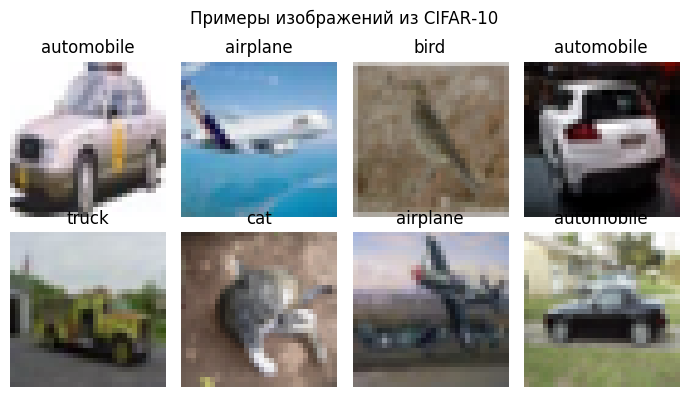

In [15]:
images, labels = next(iter(train_loader))

def denorm(img_tensor):
    # разворачиваем нормализацию для отображения
    img = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = img * std + mean
    return np.clip(img, 0, 1)

plt.figure(figsize=(7, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denorm(images[i]))
    plt.title(classes[labels[i].item()])
    plt.axis("off")
plt.suptitle("Примеры изображений из CIFAR‑10")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным (заполняется студентом)

Опишите в 3–5 предложениях:
- какие классы по картинкам вам кажутся наиболее сложными для различения;
- есть ли визуальный шум/размытость;
- насколько задача кажется вам сложнее/проще, чем MNIST.


In [17]:
data_comment = """На первый взгляд для меня было трудно отличить изображение птицы. Оно похоже и на кота, и на лягушку.
    Посмотрев несколько картинок после перезапуска было и такое, что сложно было отличить кота. 
    Была картинка с глазом оленя, я подумала, что это лошадь.
    Картинки с автомобилем и грузовиками более менее понятные. 

Шум и размытость присутсвуют. Из-за этого сложнее отличать некоторые категории.

Данная задача для меня кажется легче, чем MNIST. 
    Большое акцентное изображение для глаза понимается проще, чем рукописные цифры разными почерками.
"""
print(data_comment)

На первый взгляд для меня было трудно отличить изображение птицы. Оно похоже и на кота, и на лягушку.
    Посмотрев несколько картинок после перезапуска было и такое, что сложно было отличить кота. 
    Была картинка с глазом оленя, я подумала, что это лошадь.
    Картинки с автомобилем и грузовиками более менее понятные. 

Шум и размытость присутсвуют. Из-за этого сложнее отличать некоторые категории.

Данная задача для меня кажется легче, чем MNIST. 
    Большое акцентное изображение для глаза понимается проще, чем рукописные цифры разными почерками.



## 4. Архитектура CNN (исходный вариант)

В этой лабораторной важно не просто запустить готовый код, а **понимать** свою архитектуру и уметь её менять.

Задайте базовый вариант сети:
- несколько блоков `Conv2d → ReLU → MaxPool2d`;
- один или два полносвязных слоя после свёрток;
- выходной слой с 10 логитами.

Ниже — пример архитектуры. В своей работе вы **обязаны** попробовать хотя бы ещё один вариант (с другим числом каналов/слоёв) и сравнить результаты.


In [43]:
class SimpleCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCIFARCNN(num_classes=len(classes)).to(device)
print(model)

SimpleCIFARCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [ ]:
# # МОЙ ПРИМЕР С ДРОПАУТ
# class SimpleCIFARCNN(nn.Module):
#     def __init__(self, num_classes=10):
#         super().__init__()
#         self.features = nn.Sequential(
#             nn.Conv2d(3, 32, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2),   # 32x32 -> 16x16

#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2),   # 16x16 -> 8x8

#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2)    # 8x8 -> 4x4
#         )

#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(128 * 4 * 4, 256),
#             nn.ReLU(),
#             nn.Dropout(0.5), 
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.classifier(x)
#         return x

# model = SimpleCIFARCNN(num_classes=len(classes)).to(device)
# print(model)

SimpleCIFARCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


### Ваш комментарий к архитектуре

Ответьте коротко:
- почему вы считаете, что такого размера/глубины сети **должно** быть примерно достаточно для CIFAR‑10 (или, наоборот, нет);
- какие альтернативы вы планируете попробовать (например, другой размер фильтров, дополнительные свёрточные слои, Dropout).


In [44]:
arch_comment = """Сеть имеет 3 сверточных блока и 2 полносвязных слоя, поэтому думаю, что она достаточно глубокая для CIFAR‑10, поскольку:
    изображение маленькое 32*32; 
    3 сверточных блока позволяют выявлять сложные признаки;
    число каналоов позволяют распознавать больше признаков.

Также я добавила к этой архитектуре Dropout, чтобы посмотреть переобучается ли модель.


"""
print(arch_comment)

Сеть имеет 3 сверточных блока и 2 полносвязных слоя, поэтому думаю, что она достаточно глубокая для CIFAR‑10, поскольку:
    изображение маленькое 32*32; 
    3 сверточных блока позволяют выявлять сложные признаки;
    число каналоов позволяют распознавать больше признаков.

Также я добавила к этой архитектуре Dropout, чтобы посмотреть переобучается ли модель.





## 5. Функция потерь, оптимизатор и общий цикл обучения

Используем:
- `CrossEntropyLoss` для многоклассовой классификации;
- один из оптимизаторов (`SGD`, `Adam` и т.п.) с выбранным `learning_rate`.

В ходе работы вы должны попробовать хотя бы одну альтернативную настройку (другой `lr` и/или другой оптимизатор) и сравнить с базовой.


In [45]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


In [46]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Обучение базовой модели

Запустим обучение на несколько эпох, сохраняя историю loss/accuracy.

Рекомендуется:
- начать с небольшого числа эпох (например, 5–8);
- затем увеличить и посмотреть, появляется ли переобучение.


In [47]:
num_epochs = 5  # попробуйте изменить и сравнить результаты

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Эпоха 1/5: train_loss=1.3784, train_acc=0.5020, test_loss=1.1075, test_acc=0.6110
Эпоха 2/5: train_loss=0.9504, train_acc=0.6655, test_loss=0.8998, test_acc=0.6889
Эпоха 3/5: train_loss=0.7832, train_acc=0.7257, test_loss=0.8119, test_acc=0.7220
Эпоха 4/5: train_loss=0.6565, train_acc=0.7701, test_loss=0.7766, test_acc=0.7368
Эпоха 5/5: train_loss=0.5531, train_acc=0.8055, test_loss=0.7391, test_acc=0.7558


In [ ]:
# без дропаута с lr=0.001 Adam
# Эпоха 1/5: train_loss=1.3784, train_acc=0.5020, test_loss=1.1075, test_acc=0.6110
# Эпоха 2/5: train_loss=0.9504, train_acc=0.6655, test_loss=0.8998, test_acc=0.6889
# Эпоха 3/5: train_loss=0.7832, train_acc=0.7257, test_loss=0.8119, test_acc=0.7220
# Эпоха 4/5: train_loss=0.6565, train_acc=0.7701, test_loss=0.7766, test_acc=0.7368
# Эпоха 5/5: train_loss=0.5531, train_acc=0.8055, test_loss=0.7391, test_acc=0.7558

# с дропаут с lr=0.001 SGD momentum=0.9
# Эпоха 1/5: train_loss=2.3029, train_acc=0.1000, test_loss=2.3028, test_acc=0.1000
# Эпоха 2/5: train_loss=2.3028, train_acc=0.0985, test_loss=2.3027, test_acc=0.1000
# Эпоха 3/5: train_loss=2.3027, train_acc=0.1000, test_loss=2.3026, test_acc=0.1000
# Эпоха 4/5: train_loss=2.3026, train_acc=0.0991, test_loss=2.3026, test_acc=0.1000

# для  дропаут с lr=0.01 SGD momentum=0.9 похожая история, не стала ждать обучения

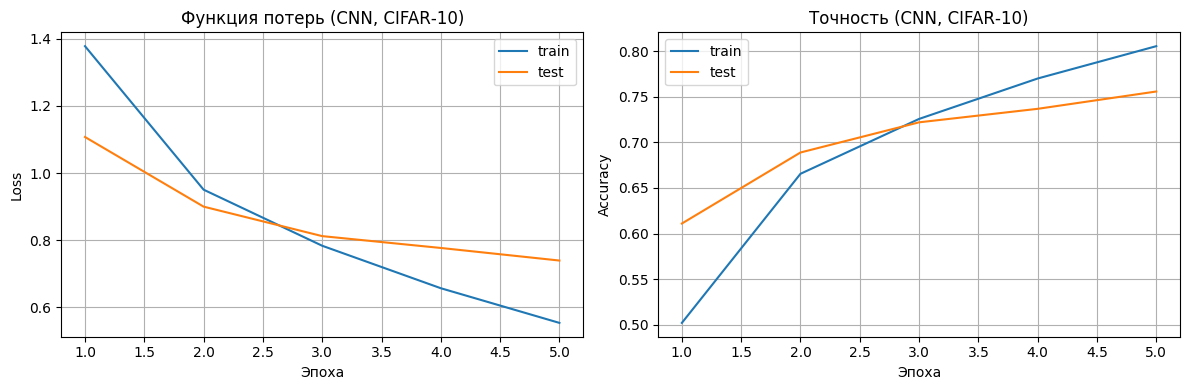

Финальная точность: train=0.8055, test=0.7558


In [48]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (CNN, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (CNN, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Анализ кривых обучения (заполняется студентом)

Опишите в 6–8 предложениях:
- как ведут себя train/test loss (сходятся ли, расходятся ли);
- есть ли заметный разрыв между train и test accuracy;
- кажется ли вам, что модель уже переобучилась или ещё недообучена;
- какие изменения (архитектуры, lr, числа эпох) вы бы попробовали дальше.


In [50]:
training_analysis = """Я проводила эксперементы на 5 эпохах, потому что обучение долгое, больше не добавляла.
Эксмперементы проводила на предложенной архитектуре и на этой же, но с добавлением дропаута.
В отдельной ячейке есть результаты с описанием использованных параметров.
Второй эксперимент совсем неудачный.

Для предложенной Вами архитектуры следующее:

- train и test loss постепенно уменьшаются. test loss падает чуть меделенне с 1.1 до 0.74. А train loss с 1.38 до 0.55.
    Кривые сходятся, но есть небольшой разрыв, думаю, что на бОльших эпохах был бы меньше.

- Для точности анологичная ситуация, как и с потерями. train accuracy растет быстрее, с 0.5 до 0.8.
    test accuracy растет с 0.6 до 0.75. 
    Разрыв есть, но также небольшой.

- Скорее всего модель еще недообучилась, и не переобучилась. Необходимо продолжить обучение с более высоким количеством эпох.

- Я бы попробовала добавить больше эпох, оставив модель на оптмизаторе Adam. 
    Также можно было бы попробовать изменить архитектуру, например увеличить количество фильтров в свёрточных слоях или нейронов в полносвязных слоях.


"""
print(training_analysis)

Я проводила эксперементы на 5 эпохах, потому что обучение долгое, больше не добавляла.
Эксмперементы проводила на предложенной архитектуре и на этой же, но с добавлением дропаута.
В отдельной ячейке есть результаты с описанием использованных параметров.
Второй эксперимент совсем неудачный.

Для предложенной Вами архитектуры следующее:

- train и test loss постепенно уменьшаются. test loss падает чуть меделенне с 1.1 до 0.74. А train loss с 1.38 до 0.55.
    Кривые сходятся, но есть небольшой разрыв, думаю, что на бОльших эпохах был бы меньше.

- Для точности анологичная ситуация, как и с потерями. train accuracy растет быстрее, с 0.5 до 0.8.
    test accuracy растет с 0.6 до 0.75. 
    Разрыв есть, но также небольшой.

- Скорее всего модель еще недообучилась, и не переобучилась. Необходимо продолжить обучение с более высоким количеством эпох.

- Я бы попробовала добавить больше эпох, оставив модель на оптмизаторе Adam. 
    Также можно было бы попробовать изменить архитектуру, например

## 7. Примеры правильных и неправильных предсказаний

Посмотрим на несколько изображений, которые модель классифицирует верно и неверно, чтобы понять, где ей сложнее всего.


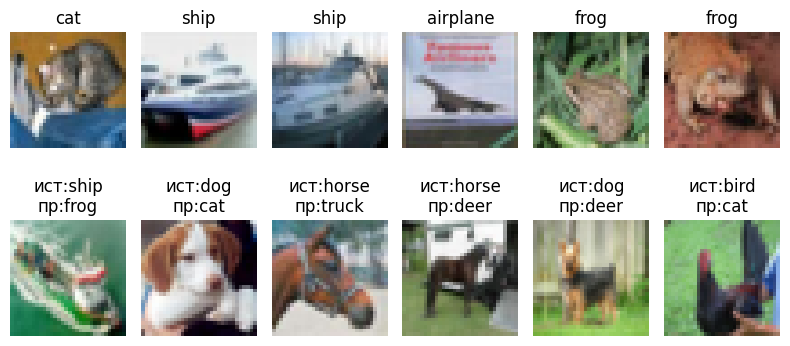

In [51]:
model.eval()
correct_imgs, correct_true, correct_pred = [], [], []
wrong_imgs, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for img, lab, pr in zip(images, labels, preds):
            if lab == pr and len(correct_imgs) < 6:
                correct_imgs.append(img.cpu())
                correct_true.append(lab.cpu().item())
                correct_pred.append(pr.cpu().item())
            if lab != pr and len(wrong_imgs) < 6:
                wrong_imgs.append(img.cpu())
                wrong_true.append(lab.cpu().item())
                wrong_pred.append(pr.cpu().item())
        if len(correct_imgs) >= 6 and len(wrong_imgs) >= 6:
            break

plt.figure(figsize=(8, 4))
for i in range(len(correct_imgs)):
    plt.subplot(2, 6, i + 1)
    plt.imshow(denorm(correct_imgs[i]))
    plt.title(classes[correct_true[i]])
    plt.axis("off")
for i in range(len(wrong_imgs)):
    plt.subplot(2, 6, 6 + i + 1)
    plt.imshow(denorm(wrong_imgs[i]))
    true_label = classes[wrong_true[i]]
    pred_label = classes[wrong_pred[i]]
    plt.title(f"ист:{true_label}\nпр:{pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Комментарий по ошибкам

Ответьте кратко:
- какие пары классов чаще всего путаются в ваших примерах;
- выглядят ли эти ошибки "человечески понятными" или, наоборот, странными;
- есть ли примеры, где вы сами сомневались бы в правильном классе.


In [ ]:
errors_comment = """ЗДЕСЬ ОПИШИТЕ НЕСКОЛЬКО НАБЛЮДЕНИЙ О ТОМ, ЧТО МОДЕЛЬ ПУТАЕТ.
Укажите хотя бы 1–2 пары классов, которые чаще всего перепутаны
в ваших примерах."""
print(errors_comment)

## 8. Эксперименты по улучшению модели

В **самостоятельной** части лабораторной вы должны будете:
- изменить архитектуру (добавить/убрать слой, поменять число каналов, добавить Dropout/BatchNorm);
- изменить настройки обучения (другой оптимизатор, lr, число эпох);
- сравнить **минимум два** варианта модели по test accuracy и кривым обучения.

Здесь не приводится готовый код, чтобы не превращать задание в копирование. Используйте функции и блоки выше как строительные кирпичики.


## 9. Итоговые выводы по лабораторной

В конце опишите:
- до какой тестовой точности вы дошли для разных вариантов моделей и при каких настройках;
- какие изменения архитектуры/гиперпараметров дали наибольший эффект;
- что для вас стало главным практическим выводом о работе CNN на CIFAR‑10 (например, чувствительность к lr, важность аугментаций, глубина сети и т.п.).

Пишите 10–15 предложений, ссылаясь на **свои** эксперименты, а не на теорию из интернета.


In [ ]:
final_summary = """ЗДЕСЬ НАПИШИТЕ ИТОГОВЫЙ ТЕКСТ ПО ЛАБОРАТОРНОЙ.
Упомяните конкретные цифры (test accuracy для разных моделей),
и сформулируйте свои личные правила: какую CNN и с какими настройками
вы бы стали пробовать первой в новой задаче, похожей на CIFAR‑10."""
print(final_summary)